In [2]:
# Install Kaggle API if not already installed
!pip install kaggle

# Upload kaggle.json manually if not done already
from google.colab import files
print("Please upload your kaggle.json file (make sure it's named kaggle.json).")
uploaded = files.upload()  # Upload kaggle.json file manually when prompted

# Move kaggle.json to correct location
import os
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 600)

# Now use the Kaggle API to download the dataset
!kaggle datasets download -d atulyakumar98/pothole-detection-dataset --force

# Unzip the downloaded dataset
!unzip -q pothole-detection-dataset.zip -d /content/pothole_detection_data

# Verify the contents of the dataset directory
import os
dataset_dir = '/content/pothole_detection_data'
if os.path.exists(dataset_dir):
    print("Files in dataset directory:", os.listdir(dataset_dir))
else:
    print("Dataset directory not found; please check if the dataset downloaded correctly.")

Please upload your kaggle.json file (make sure it's named kaggle.json).


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/atulyakumar98/pothole-detection-dataset
License(s): CC0-1.0
 99% 192M/194M [00:05<00:00, 41.6MB/s]
100% 194M/194M [00:05<00:00, 36.6MB/s]
Files in dataset directory: ['potholes', 'normal']


Found 546 images belonging to 2 classes.
Found 135 images belonging to 2 classes.
Found 135 images belonging to 2 classes.
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 30s 30s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 19s 19s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 19s 19s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 20s 20s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 20s 20s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 22s 22s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 19s 19s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 20s 20s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 20s 20s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 21s 21s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 20s 20s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 19s 19s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 21s 21s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 19s 19s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 19s 19s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 19s 19s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 19s 19s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 22s 22s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 20s 20s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 21s 21s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 19s 1

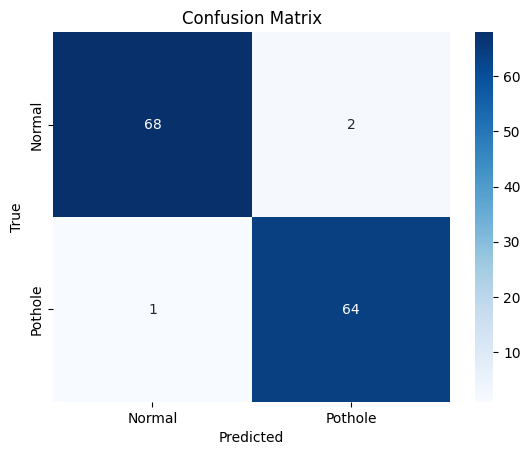

In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Paths
data_path = '/content/pothole_detection_data'

# Image preprocessing
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
train_gen = datagen.flow_from_directory(data_path, target_size=(224, 224), batch_size=32, class_mode='binary', subset='training', shuffle=True)
val_gen = datagen.flow_from_directory(data_path, target_size=(224, 224), batch_size=32, class_mode='binary', subset='validation', shuffle=False)
test_gen = datagen.flow_from_directory(data_path, target_size=(224, 224), batch_size=32, class_mode='binary', subset='validation', shuffle=False)

# Load a pre-trained model for feature extraction (VGG16 in this case)
base_model = tf.keras.applications.VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model layers
base_model.trainable = False

# Define a new model for feature extraction
def feature_extractor(base_model, generator):
    features = []
    labels = []

    # Loop over the batches from the data generator
    for batch_data, batch_labels in generator:
        batch_features = base_model.predict(batch_data)
        batch_features = batch_features.reshape(batch_features.shape[0], -1)  # Flatten the features
        features.extend(batch_features)
        labels.extend(batch_labels)

        if len(features) >= generator.samples:
            break

    return np.array(features), np.array(labels)

# Extract features from the training, validation, and test data
X_train, y_train = feature_extractor(base_model, train_gen)
X_val, y_val = feature_extractor(base_model, val_gen)
X_test, y_test = feature_extractor(base_model, test_gen)

# Apply PCA to reduce dimensionality
pca = PCA(n_components=100)  # Number of components to keep (tune as necessary)
X_train_pca = pca.fit_transform(X_train)
X_val_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test)

# Train an SVM classifier on the PCA-reduced features
svm = SVC(kernel='linear', C=1.0)  # Using a linear kernel
svm.fit(X_train_pca, y_train)

# Evaluate the SVM model on the validation set
y_val_pred = svm.predict(X_val_pca)
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

# Evaluate the SVM model on the test set
y_test_pred = svm.predict(X_test_pca)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# Classification Report for the Test Set
cr = classification_report(y_test, y_test_pred)
print(f"Classification Report for Test Set:\n{cr}")

# Confusion Matrix for the Test Set
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Pothole'], yticklabels=['Normal', 'Pothole'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


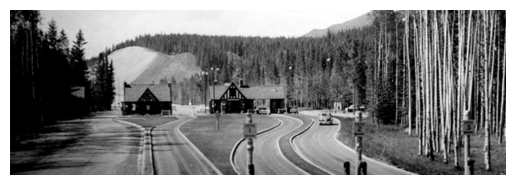

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prediction: normal


In [4]:
import numpy as np
import cv2
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Load and display the test image
img_path = '/content/pothole_detection_data/normal/10.jpg'
test_image = image.load_img(img_path, target_size=(224, 224))  # Resize to match VGG16 input size
plt.imshow(cv2.imread(img_path))
plt.axis('off')  # Hide axes
plt.show()

# Preprocess the test image for VGG16
test_image = image.img_to_array(test_image)
test_image = np.expand_dims(test_image, axis=0)  # Add batch dimension
test_image = test_image / 255.0  # Rescale to [0,1] range

# Extract features using the pre-trained VGG16 model
test_features = base_model.predict(test_image)
test_features = test_features.reshape(1, -1)  # Flatten for PCA input

# Apply PCA transformation to the test features
test_features_pca = pca.transform(test_features)

# Make prediction with the SVM model
result = svm.predict(test_features_pca)
prediction_label = 'pothole' if result[0] == 1 else 'normal'

# Display the prediction result
print(f"Prediction: {prediction_label}")

